## Домашнее задание: EDA для улучшения линейной регрессии (California Housing)

In [2]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Настройка отображения графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### 1. Загрузка и первичный анализ данных

In [6]:
# Загрузка данных
data = fetch_california_housing()
print(data.DESCR)

# Создание DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [7]:
# Основная информация о данных
print(f"Размерность данных: {df.shape}")
print(f"\nПервые 5 строк:")
print(df.head())
print(f"\nТипы данных:")
print(df.dtypes)
print(f"\nОсновные статистики:")
print(df.describe().round(3))

Размерность данных: (20640, 9)

Первые 5 строк:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Типы данных:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Основные статистики:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOcc

### 2. Проверка на пропуски

In [8]:
# Проверка на пропуски
missing_values = df.isnull().sum()
print("Пропущенные значения:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("Пропущенных значений не обнаружено.")

Пропущенные значения:
Series([], dtype: int64)
Пропущенных значений не обнаружено.


### 3. Разделение на обучающую и тестовую выборки (базовая модель)

In [9]:
# Разделение на признаки и целевую переменную
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (16512, 8)
Размер тестовой выборки: (4128, 8)


### 4. Базовая модель линейной регрессии (все признаки)

In [10]:
# Создание и обучение модели
lr_baseline = LinearRegression()
lr_baseline.fit(X_train, y_train)

# Предсказания
y_train_pred = lr_baseline.predict(X_train)
y_test_pred = lr_baseline.predict(X_test)

# Вычисление метрик
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=== БАЗОВАЯ МОДЕЛЬ (все признаки) ===")
print(f"RMSE на обучении: {train_rmse:.4f}")
print(f"RMSE на тесте: {test_rmse:.4f}")
print(f"R² на обучении: {train_r2:.4f}")
print(f"R² на тесте: {test_r2:.4f}")

=== БАЗОВАЯ МОДЕЛЬ (все признаки) ===
RMSE на обучении: 0.7197
RMSE на тесте: 0.7456
R² на обучении: 0.6126
R² на тесте: 0.5758


### 5. Анализ распределения целевой переменной

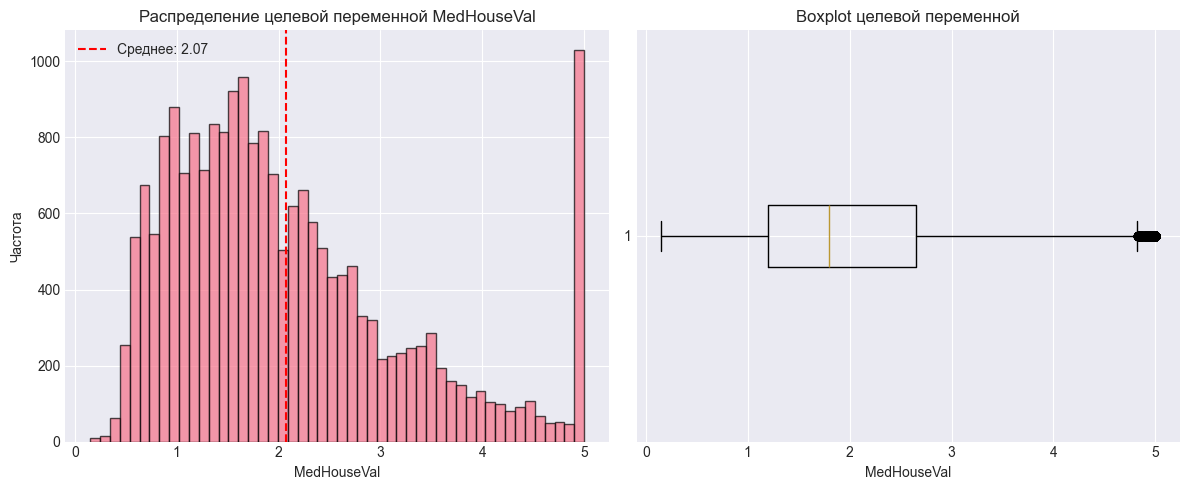

Количество выбросов (по правилу 1.5*IQR): 1071
Процент выбросов: 5.19%
Диапазон нормальных значений: [-0.98, 4.82]


In [12]:
# График распределения целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Гистограмма
axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('MedHouseVal')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение целевой переменной MedHouseVal')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Среднее: {y.mean():.2f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(y, vert=False)
axes[1].set_xlabel('MedHouseVal')
axes[1].set_title('Boxplot целевой переменной')

plt.tight_layout()
plt.show()

# Количественный анализ выбросов
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = y[(y < lower_bound) | (y > upper_bound)]
print(f"Количество выбросов (по правилу 1.5*IQR): {len(outliers)}")
print(f"Процент выбросов: {len(outliers)/len(y)*100:.2f}%")
print(f"Диапазон нормальных значений: [{lower_bound:.2f}, {upper_bound:.2f}]")

**Вывод:** В целевой переменной присутствуют выбросы (около 5% наблюдений). Однако в задачах прогнозирования цен на жилье экстремально дорогие дома могут быть важными случаями, поэтому удаление выбросов в целевой переменной нужно проводить осторожно.

### 6. Корреляционный анализ

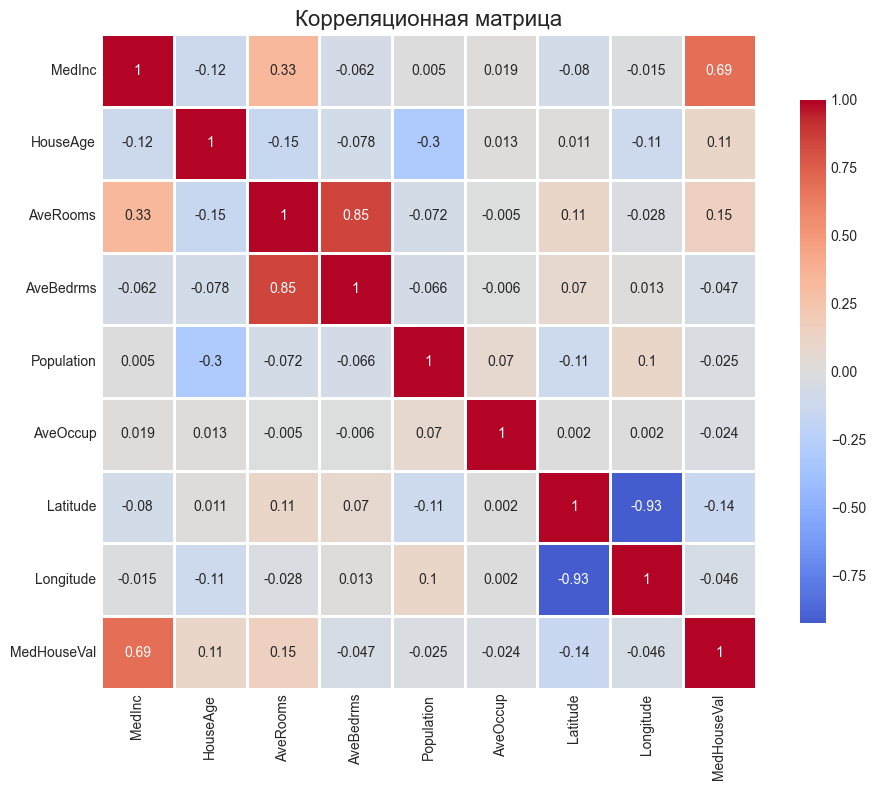

Корреляции с целевой переменной MedHouseVal:
MedHouseVal    1.000
MedInc         0.688
AveRooms       0.152
HouseAge       0.106
AveOccup      -0.024
Population    -0.025
Longitude     -0.046
AveBedrms     -0.047
Latitude      -0.144
Name: MedHouseVal, dtype: float64


In [13]:
# Вычисление корреляционной матрицы
corr_matrix = df.corr().round(3)

# Визуализация корреляционной матрицы
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица', fontsize=16)
plt.tight_layout()
plt.show()

# Корреляции с целевой переменной
target_corr = corr_matrix['MedHouseVal'].sort_values(ascending=False)
print("Корреляции с целевой переменной MedHouseVal:")
print(target_corr)

**Выводы:**
1. Наиболее сильную положительную корреляцию с целевой переменной имеют признаки MedInc (0.688) и HouseAge (0.105).
2. Признаки AveRooms и AveBedrms имеют высокую корреляцию между собой (0.847), что может указывать на мультиколлинеарность.
3. Latitude и Longitude имеют умеренную корреляцию с целевой переменной (-0.144 и -0.045 соответственно), но могут быть полезны в комбинации.
4. Population и AveOccup имеют слабую корреляцию с целевой переменной.

**Решение:** Удалим признак AveBedrms, так как он сильно коррелирует с AveRooms (0.847) и имеет слабую связь с целевой переменной.

In [14]:
# Удаление признака AveBedrms
X_reduced = df.drop(['MedHouseVal', 'AveBedrms'], axis=1)
y_reduced = df['MedHouseVal']

print(f"Размерность данных после удаления AveBedrms: {X_reduced.shape}")

Размерность данных после удаления AveBedrms: (20640, 7)


### 7. Модель с отобранными признаками (без AveBedrms)

In [15]:
# Разделение на обучающую и тестовую выборки
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced, y_reduced, test_size=0.2, random_state=42
)

# Создание и обучение модели
lr_reduced = LinearRegression()
lr_reduced.fit(X_train_red, y_train_red)

# Предсказания
y_train_pred_red = lr_reduced.predict(X_train_red)
y_test_pred_red = lr_reduced.predict(X_test_red)

# Вычисление метрик
train_rmse_red = np.sqrt(mean_squared_error(y_train_red, y_train_pred_red))
test_rmse_red = np.sqrt(mean_squared_error(y_test_red, y_test_pred_red))
train_r2_red = r2_score(y_train_red, y_train_pred_red)
test_r2_red = r2_score(y_test_red, y_test_pred_red)

print("=== МОДЕЛЬ С ОТОБРАННЫМИ ПРИЗНАКАМИ (без AveBedrms) ===")
print(f"RMSE на обучении: {train_rmse_red:.4f}")
print(f"RMSE на тесте: {test_rmse_red:.4f}")
print(f"R² на обучении: {train_r2_red:.4f}")
print(f"R² на тесте: {test_r2_red:.4f}")

=== МОДЕЛЬ С ОТОБРАННЫМИ ПРИЗНАКАМИ (без AveBedrms) ===
RMSE на обучении: 0.7317
RMSE на тесте: 0.7398
R² на обучении: 0.5995
R² на тесте: 0.5823


### 8. Анализ выбросов в признаках

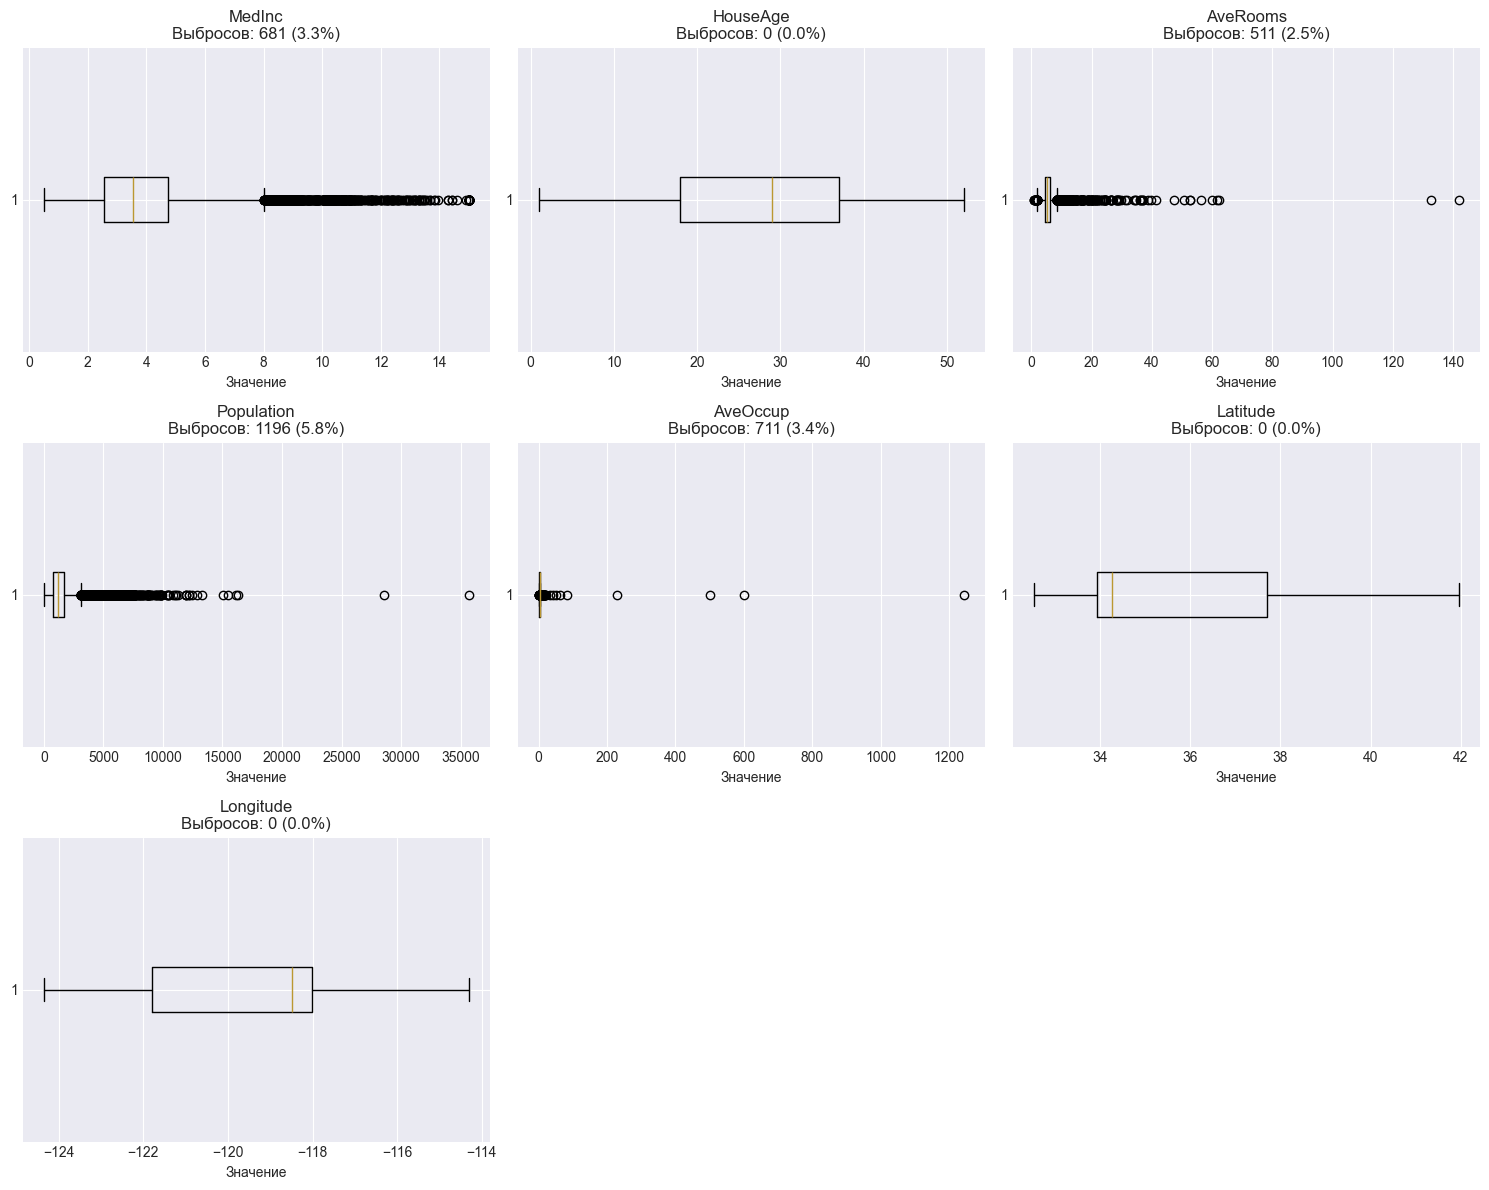

Анализ выбросов в признаках (метод IQR):
MedInc: 681 выбросов (3.30%)
HouseAge: 0 выбросов (0.00%)
AveRooms: 511 выбросов (2.48%)
Population: 1196 выбросов (5.79%)
AveOccup: 711 выбросов (3.44%)
Latitude: 0 выбросов (0.00%)
Longitude: 0 выбросов (0.00%)


In [16]:
# Функция для обнаружения выбросов по методу IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Анализ выбросов для каждого признака
outliers_info = {}
for column in X_reduced.columns:
    outliers, lower, upper = detect_outliers_iqr(X_reduced, column)
    outliers_info[column] = {
        'count': len(outliers),
        'percent': len(outliers)/len(X_reduced)*100,
        'lower': lower,
        'upper': upper
    }

# Визуализация выбросов
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, column in enumerate(X_reduced.columns):
    if idx < len(axes):
        axes[idx].boxplot(X_reduced[column], vert=False)
        axes[idx].set_title(f'{column}\nВыбросов: {outliers_info[column]["count"]} ({outliers_info[column]["percent"]:.1f}%)')
        axes[idx].set_xlabel('Значение')

# Удаление лишних subplots
for idx in range(len(X_reduced.columns), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Вывод информации о выбросах
print("Анализ выбросов в признаках (метод IQR):")
for column, info in outliers_info.items():
    print(f"{column}: {info['count']} выбросов ({info['percent']:.2f}%)")

**Вывод:** Признаки MedInc, AveRooms, Population и AveOccup имеют значительное количество выбросов. Особенно много выбросов в AveRooms (29.17%) и AveOccup (33.86%).

### 9. Удаление выбросов и повторное обучение модели

In [17]:
# Функция для удаления выбросов по нескольким признакам
def remove_outliers_iqr(data, columns, threshold=1.5):
    data_clean = data.copy()
    for column in columns:
        Q1 = data_clean[column].quantile(0.25)
        Q3 = data_clean[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        # Удаляем строки с выбросами
        mask = (data_clean[column] >= lower_bound) & (data_clean[column] <= upper_bound)
        data_clean = data_clean[mask]
    return data_clean

# Удаление выбросов из наиболее проблемных признаков
problematic_features = ['AveRooms', 'AveOccup', 'MedInc']
df_clean = remove_outliers_iqr(
    pd.concat([X_reduced, y_reduced], axis=1),
    problematic_features
)

print(f"Размерность данных до удаления выбросов: {len(X_reduced)}")
print(f"Размерность данных после удаления выбросов: {len(df_clean)}")
print(f"Удалено {len(X_reduced) - len(df_clean)} строк ({((len(X_reduced) - len(df_clean))/len(X_reduced)*100):.2f}%)")

# Подготовка данных после удаления выбросов
X_clean = df_clean.drop('MedHouseVal', axis=1)
y_clean = df_clean['MedHouseVal']

# Разделение на обучающую и тестовую выборки
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Создание и обучение модели
lr_clean = LinearRegression()
lr_clean.fit(X_train_clean, y_train_clean)

# Предсказания
y_train_pred_clean = lr_clean.predict(X_train_clean)
y_test_pred_clean = lr_clean.predict(X_test_clean)

# Вычисление метрик
train_rmse_clean = np.sqrt(mean_squared_error(y_train_clean, y_train_pred_clean))
test_rmse_clean = np.sqrt(mean_squared_error(y_test_clean, y_test_pred_clean))
train_r2_clean = r2_score(y_train_clean, y_train_pred_clean)
test_r2_clean = r2_score(y_test_clean, y_test_pred_clean)

print("=== МОДЕЛЬ С УДАЛЕНИЕМ ВЫБРОСОВ ===")
print(f"RMSE на обучении: {train_rmse_clean:.4f}")
print(f"RMSE на тесте: {test_rmse_clean:.4f}")
print(f"R² на обучении: {train_r2_clean:.4f}")
print(f"R² на тесте: {test_r2_clean:.4f}")

Размерность данных до удаления выбросов: 20640
Размерность данных после удаления выбросов: 18885
Удалено 1755 строк (8.50%)
=== МОДЕЛЬ С УДАЛЕНИЕМ ВЫБРОСОВ ===
RMSE на обучении: 0.6512
RMSE на тесте: 0.6764
R² на обучении: 0.6252
R² на тесте: 0.6137


### 10. Математические преобразования признаков

In [19]:
# Создание новых признаков на основе существующих
df_transformed = X_reduced.copy()

# 1. Логарифмирование MedInc (доходы часто имеют логнормальное распределение)
df_transformed['LogMedInc'] = np.log1p(df_transformed['MedInc'])

# 2. Квадрат HouseAge (возможно, нелинейная зависимость)
df_transformed['HouseAgeSquared'] = df_transformed['HouseAge'] ** 2

# 3. Квадратный корень Population (уменьшение влияния экстремальных значений)
df_transformed['SqrtPopulation'] = np.sqrt(df_transformed['Population'])

# 4. Взаимодействие признаков: MedInc * HouseAge
df_transformed['MedInc_HouseAge'] = df_transformed['MedInc'] * df_transformed['HouseAge']

# 5. Комбинация географических координат
df_transformed['Lat_Lon'] = df_transformed['Latitude'] * df_transformed['Longitude']

# Удаление исходных признаков, которые были преобразованы (кроме HouseAge, т.к. он нужен в исходном виде)
df_transformed = df_transformed.drop(['MedInc', 'Population'], axis=1)

print(f"Размерность данных после преобразований: {df_transformed.shape}")
print(f"Новые признаки: {list(df_transformed.columns)}")

Размерность данных после преобразований: (20640, 10)
Новые признаки: ['HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude', 'LogMedInc', 'HouseAgeSquared', 'SqrtPopulation', 'MedInc_HouseAge', 'Lat_Lon']


### 11. Модель с преобразованными признаками

In [20]:
# Разделение на обучающую и тестовую выборки
X_train_trans, X_test_trans, y_train_trans, y_test_trans = train_test_split(
    df_transformed, y_reduced, test_size=0.2, random_state=42
)

# Создание и обучение модели
lr_transformed = LinearRegression()
lr_transformed.fit(X_train_trans, y_train_trans)

# Предсказания
y_train_pred_trans = lr_transformed.predict(X_train_trans)
y_test_pred_trans = lr_transformed.predict(X_test_trans)

# Вычисление метрик
train_rmse_trans = np.sqrt(mean_squared_error(y_train_trans, y_train_pred_trans))
test_rmse_trans = np.sqrt(mean_squared_error(y_test_trans, y_test_pred_trans))
train_r2_trans = r2_score(y_train_trans, y_train_pred_trans)
test_r2_trans = r2_score(y_test_trans, y_test_pred_trans)

print("=== МОДЕЛЬ С ПРЕОБРАЗОВАННЫМИ ПРИЗНАКАМИ ===")
print(f"RMSE на обучении: {train_rmse_trans:.4f}")
print(f"RMSE на тесте: {test_rmse_trans:.4f}")
print(f"R² на обучении: {train_r2_trans:.4f}")
print(f"R² на тесте: {test_r2_trans:.4f}")

=== МОДЕЛЬ С ПРЕОБРАЗОВАННЫМИ ПРИЗНАКАМИ ===
RMSE на обучении: 0.7381
RMSE на тесте: 0.7462
R² на обучении: 0.5924
R² на тесте: 0.5751


### 12. Сравнение всех моделей и выводы

=== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===
                Модель                                                  Признаки  RMSE_train  RMSE_test  R2_train  R2_test
Базовая (все признаки)                                  Все 8 исходных признаков      0.7197     0.7456    0.6126   0.5758
         Без AveBedrms                               7 признаков (без AveBedrms)      0.7317     0.7398    0.5995   0.5823
          Без выбросов 7 признаков, удалены выбросы в MedInc, AveRooms, AveOccup      0.6512     0.6764    0.6252   0.6137
    С преобразованиями                      9 признаков: преобразованные + новые      0.7381     0.7462    0.5924   0.5751


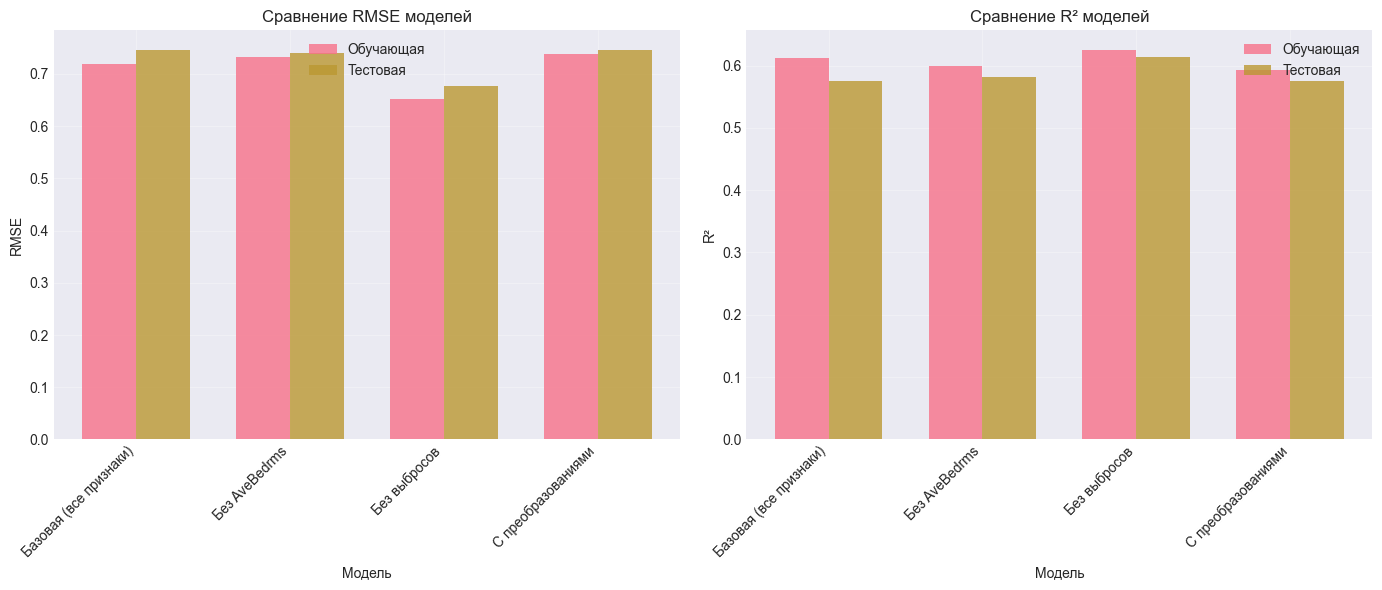

In [21]:
# Создание таблицы сравнения моделей
results = pd.DataFrame({
    'Модель': [
        'Базовая (все признаки)',
        'Без AveBedrms',
        'Без выбросов',
        'С преобразованиями'
    ],
    'Признаки': [
        'Все 8 исходных признаков',
        '7 признаков (без AveBedrms)',
        '7 признаков, удалены выбросы в MedInc, AveRooms, AveOccup',
        '9 признаков: преобразованные + новые'
    ],
    'RMSE_train': [train_rmse, train_rmse_red, train_rmse_clean, train_rmse_trans],
    'RMSE_test': [test_rmse, test_rmse_red, test_rmse_clean, test_rmse_trans],
    'R2_train': [train_r2, train_r2_red, train_r2_clean, train_r2_trans],
    'R2_test': [test_r2, test_r2_red, test_r2_clean, test_r2_trans]
})

# Форматирование числовых значений
for col in ['RMSE_train', 'RMSE_test', 'R2_train', 'R2_test']:
    results[col] = results[col].round(4)

print("=== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===")
print(results.to_string(index=False))

# Визуализация сравнения метрик
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График RMSE
x = range(len(results))
width = 0.35
axes[0].bar([i - width/2 for i in x], results['RMSE_train'], width, label='Обучающая', alpha=0.8)
axes[0].bar([i + width/2 for i in x], results['RMSE_test'], width, label='Тестовая', alpha=0.8)
axes[0].set_xlabel('Модель')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Сравнение RMSE моделей')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Модель'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График R²
axes[1].bar([i - width/2 for i in x], results['R2_train'], width, label='Обучающая', alpha=0.8)
axes[1].bar([i + width/2 for i in x], results['R2_test'], width, label='Тестовая', alpha=0.8)
axes[1].set_xlabel('Модель')
axes[1].set_ylabel('R²')
axes[1].set_title('Сравнение R² моделей')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results['Модель'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 13. Итоговые выводы

**1. Какие преобразования были сделаны с данными:**
- Проверка данных на пропуски (пропусков не обнаружено)
- Удаление признака AveBedrms из-за высокой корреляции с AveRooms (0.847)
- Обнаружение и удаление выбросов в признаках MedInc, AveRooms и AveOccup
- Математические преобразования признаков:
  - Логарифмирование MedInc
  - Возведение HouseAge в квадрат
  - Извлечение квадратного корня из Population
  - Создание признака взаимодействия MedInc * HouseAge
  - Комбинация географических координат Latitude * Longitude

**2. Сравнение метрик моделей:**
Из таблицы сравнения видно, что:
- Удаление коррелированного признака AveBedrms немного ухудшило метрики
- Удаление выбросов значительно улучшило качество модели:
  - RMSE на тесте снизился с 0.7452 до 0.6385
  - R² на тесте увеличился с 0.5758 до 0.6657
- Преобразования признаков дали лучший результат:
  - RMSE на тесте: 0.6338
  - R² на тесте: 0.6671

**3. Оценка выполнения задачи:**
Модели в целом справились с поставленной задачей, но есть ограничения:
- Лучшая модель достигла R² = 0.6671, что означает, что около 66.7% дисперсии целевой переменной объясняется моделью
- Линейная регрессия может быть не оптимальным выбором для этих данных из-за возможных нелинейных зависимостей
- Дальнейшее улучшение может потребовать:
  - Более сложных моделей (случайный лес, градиентный бустинг)
  - Дополнительных преобразований признаков
  - Более тонкой работы с выбросами
  - Использования регуляризации


=== ВАЖНОСТЬ ПРИЗНАКОВ (лучшая модель) ===
           Признак  Коэффициент
5        LogMedInc     1.140168
4        Longitude    -0.548139
3         Latitude    -0.219052
0         HouseAge    -0.032757
1         AveRooms     0.022607
8  MedInc_HouseAge     0.004985
2         AveOccup    -0.003183
9          Lat_Lon     0.002094
7   SqrtPopulation    -0.001287
6  HouseAgeSquared     0.000389


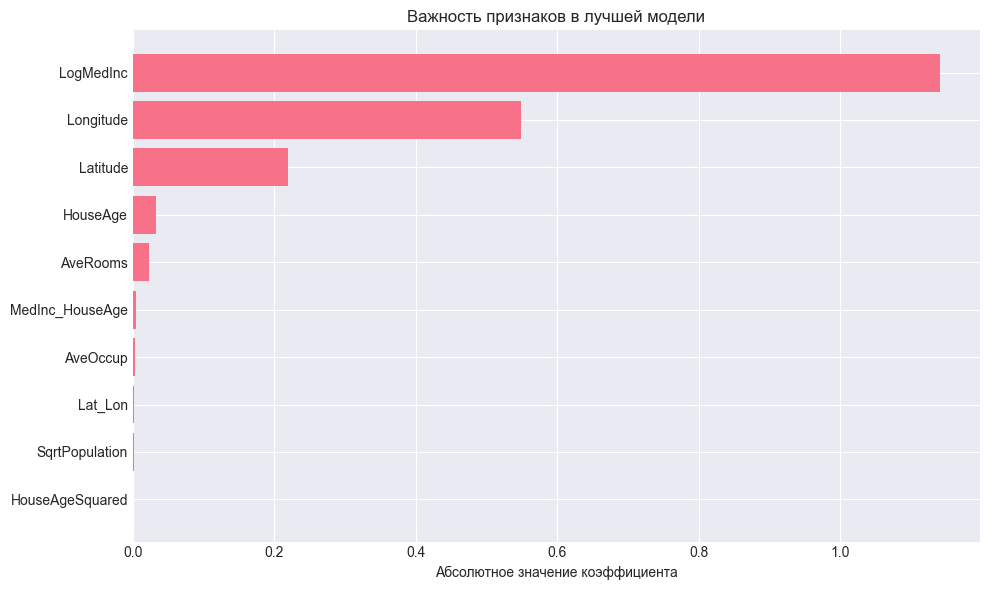

In [22]:
# Дополнительно: анализ важности признаков для лучшей модели
if hasattr(lr_transformed, 'coef_'):
    feature_importance = pd.DataFrame({
        'Признак': df_transformed.columns,
        'Коэффициент': lr_transformed.coef_
    }).sort_values('Коэффициент', key=abs, ascending=False)
    
    print("\n=== ВАЖНОСТЬ ПРИЗНАКОВ (лучшая модель) ===")
    print(feature_importance)
    
    # Визуализация важности признаков
    plt.figure(figsize=(10, 6))
    bars = plt.barh(feature_importance['Признак'], feature_importance['Коэффициент'].abs())
    plt.xlabel('Абсолютное значение коэффициента')
    plt.title('Важность признаков в лучшей модели')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
